---
# 1.1 필요 라이브러리 및 폰트 로드

In [2]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 데이터 처리 및 분석
import numpy as np
import pandas as pd
from IPython.display import display
import warnings
import platform

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)


print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)


라이브러리 로드 완료!
한글 폰트 설정 완료!


In [3]:
from scipy.stats import shapiro
from scipy import stats
from scipy.stats import levene


# 1.2 데이터 로드

In [4]:
# 1. 원본 데이터 로드
df_original_2 = pd.read_csv("../Data/for_통계_overall_data_product-2.csv")

# 3. 첫 번째 컬럼을 기준으로 분리된 데이터 프레임 생성
df_process_2 = pd.read_csv("../Data/for_통계_process_data_product-2.csv")
df_sensor_2 = pd.read_csv("../Data/for_통계_sensor_data_product-2.csv")
df_defects_2 = pd.read_csv("../Data/for_통계_defects_data_product-2.csv")

In [5]:
print(df_original_2.shape)
print(df_process_2.shape)
print(df_sensor_2.shape)
print(df_defects_2.shape)

(3328, 34)
(3328, 24)
(3328, 7)
(3328, 3)


In [6]:
df_original_2.head()

,shot_key,velocity_1,velocity_2,velocity_3,high_velocity,cylinder_pressure,rapid_rise_time,biscuit_thickness,clamping_force,cycle_time,pressure_rise_time,casting_pressure,spray_time,spray_1_time,spray_2_time,velocity_1_outlier_flag,velocity_3_outlier_flag,cylinder_pressure_outlier_flag,rapid_rise_time_outlier_flag,biscuit_thickness_outlier_flag,cycle_time_outlier_flag,casting_pressure_outlier_flag,spray_time_outlier_flag,spray_1_time_outlier_flag,melting_furnace_temp,air_pressure,coolant_temp,coolant_pressure,factory_temp,factory_humidity,factory_temp_outlier_flag,surface_defect,structural_defect,contamination_defect
0,4207011_11,0.156,0.166,0.192,2.723,265,0.012,20,357,36.55,0.041,595.0,12.5,2.0,2.2,0,0,0,0,0,1,0,0,0,671.6,6.5,26.1,2.70,33.2,57.4,0,0,0,0
1,4208012_12,0.157,0.166,0.204,2.730,265,0.014,19,359,36.50,0.040,594.0,12.5,2.0,2.2,0,0,1,0,0,0,0,0,0,672.1,6.4,26.2,2.71,33.3,57.0,0,0,0,0
2,4209013_13,0.156,0.170,0.204,2.715,265,0.012,18,361,36.50,0.041,595.0,12.5,2.0,2.2,0,0,0,0,0,0,0,0,0,672.4,6.4,26.2,2.70,33.5,56.7,0,0,0,0
3,4210014_14,0.154,0.170,0.202,2.717,265,0.011,20,364,36.50,0.042,595.0,12.5,2.0,2.2,0,0,1,0,0,0,0,0,0,672.4,6.4,26.2,2.70,33.5,56.7,0,0,0,0
4,4211015_15,0.146,0.160,0.198,2.684,265,0.012,20,357,36.50,0.042,595.0,12.5,2.0,2.2,0,0,1,0,0,0,0,0,0,672.4,6.3,26.2,2.71,33.6,56.4,0,0,0,0


# 통계 계획 수립

## 타깃이 0/1 이진 변수
Welch t-test (정규성 어느 정도 + 등분산 불만족도 가능)\
    정규성, 등분산성 검증 필요

Mann-Whitney U test (비모수)

## 타깃이 3개 이상 범주형

0 = 양품 / 1 = 표면불량 / 2 = 구조불량 / 3 = 이물질불량

ANOVA\
Welch ANOVA\
Kruskal-Wallis\

# 1단계 간단한 기술통계
평균, 중앙값, 표준편차\
최소/최대\
왜도?

In [7]:
# 1. Process, Sensor 관련 데이터의 기술통계 딸깍
def create_statistics_summary(df, df_name, exclude_cols=None):
    
    print(f"\n{'='*80}")
    print(f"{df_name} 연속형 변수 기술통계량")
    print(f"{'='*80}\n")
    
    # 1-1. exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')
    
    # 1-2. 기초 통계량
    stats_df = df_copied.describe().T
    stats_df['Skewness'] = df_copied.skew()
    
    # 1-3. 컬럼명 한글로 변경
    stats_df.rename(columns={
        'count': '개수',
        'mean': '평균',
        'std': '표준편차',
        'min': '최솟값',
        '25%': 'Q1의 경계값',
        '50%': '중앙값',
        '75%': 'Q3의 경계값',
        'max': '최댓값',
        'Skewness': '왜도'
    }, inplace=True)
    
    display(stats_df)

In [8]:
# 2. 0/1 이진 변수 요약 딸깍
def create_binary_summary(df, df_name, exclude_cols=None):
    
    print(f"\n{'='*80}")
    print(f"{df_name} 0/1 이진 변수 요약")
    print(f"{'='*80}\n")
    
    # 2-1. exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')
    
    # 2-2. 요약표 생성
    summary_df = pd.DataFrame(index=df_copied.columns)
    summary_df['개수'] = df_copied.count()
    summary_df['0의 개수'] = (df_copied == 0).sum()
    summary_df['1의 개수'] = (df_copied == 1).sum()
    summary_df['1의 비율(%)'] = (df_copied.mean() * 100).round(2)
    summary_df['0의 비율(%)'] = ((1 - df_copied.mean()) * 100).round(2)
    
    display(summary_df)

In [9]:
create_statistics_summary(df_process_2, "process", exclude_cols="product_type" )
create_statistics_summary(df_sensor_2, "sensor")
create_binary_summary(df_defects_2, "defects",)


process 연속형 변수 기술통계량



,개수,평균,표준편차,최솟값,Q1의 경계값,중앙값,Q3의 경계값,최댓값,왜도
velocity_1,3328.0,0.154473,0.004836,0.139961,0.1515,0.156,0.158,0.162,-0.721449
velocity_2,3328.0,0.168620,0.004023,0.158000,0.1660,0.168,0.172,0.178,0.066497
velocity_3,3328.0,0.202256,0.004921,0.187391,0.2000,0.202,0.206,0.216,-0.162441
high_velocity,3328.0,2.553245,0.071882,2.470000,2.5140,2.524,2.538,2.744,1.57937
cylinder_pressure,3328.0,265.000000,0.000000,265.000000,265.0000,265.000,265.000,265.000,0.0
rapid_rise_time,3328.0,0.011660,0.000887,0.009000,0.0110,0.012,0.012,0.014,-0.645101
biscuit_thickness,3328.0,17.610276,1.370777,14.000000,17.0000,18.000,19.000,22.000,-0.135318
clamping_force,3328.0,370.342548,10.160827,346.000000,361.0000,375.000,379.000,388.000,-0.470378
cycle_time,3328.0,35.876908,0.300762,35.350000,35.8000,36.000,36.100,36.550,-0.623103
pressure_rise_time,3328.0,0.036638,0.002946,0.031000,0.0340,0.036,0.040,0.045,0.692732



sensor 연속형 변수 기술통계량



,개수,평균,표준편차,최솟값,Q1의 경계값,중앙값,Q3의 경계값,최댓값,왜도
melting_furnace_temp,3328.0,655.703996,8.494439,635.300000,648.70,655.4,662.50,678.10,0.273951
air_pressure,3328.0,6.120583,0.677288,4.600000,5.60,6.2,6.80,7.10,-0.378966
coolant_temp,3328.0,26.923347,0.551408,25.900000,26.50,26.8,27.30,28.10,0.282971
coolant_pressure,3328.0,2.689742,0.056365,2.580000,2.63,2.7,2.74,2.79,-0.210328
factory_temp,3328.0,32.572087,1.521800,28.003531,31.60,32.0,32.50,37.00,1.411270
factory_humidity,3328.0,63.190775,6.631947,45.500000,61.80,64.3,69.10,72.30,-1.083763
factory_temp_outlier_flag,3328.0,0.000601,0.024511,0.000000,0.00,0.0,0.00,1.00,40.773755



defects 0/1 이진 변수 요약



,개수,0의 개수,1의 개수,1의 비율(%),0의 비율(%)
surface_defect,3328,3132,196,5.89,94.11
structural_defect,3328,2550,778,23.38,76.62
contamination_defect,3328,3309,19,0.57,99.43


### 0. 공통 해석
process, sensor, defects 데이터는 총 3,328개의 관측치로 구성되어 있다.

### 1. process 데이터 기술통계 해석
velocity_1, velocity_2, velocity_3, cycle_time, pressure_rise_time 등은 표준편차가 크지 않아 전반적으로 공정 조건이 일정하게 유지

high_velocity, spray_time, spray_2_time은 왜도가 상대적으로 크게 나타나 일부 값이 한쪽으로 치우친 비대칭 분포

cylinder_pressure와 spray_1_time의 값이 왜 0으로 나오지? 클램핑으로 값을 묶어서 저렇게 됨

### 2. sensor 데이터 기술통계 해석
melting_furnace_temp, coolant_temp, coolant_pressure는 평균 주변에 비교적 고르게 분포하며 큰 변동은 보이지 않음

반면 factory_temp는 양의 왜도, factory_humidity는 음의 왜도가 비교적 크게 나타나 환경 변수 일부는 비대칭 분포

### 3. defects 데이터 기술통계 해석
surface_defect, structural_defect, contamination_defect의 3개 이진 변수로 구성되어 있다.\
surface_defect의 불량 비율은 5.89%, structural_defect는 23.38%, contamination_defect는 0.57%로 나타났다.

이 중 structural_defect가 가장 빈도가 높아 상대적으로 분석 안정성이 높고, contamination_defect는 발생 건수가 19건으로 매우 적어 심한 클래스 불균형을 보인다.

이후 통계 검정 및 머신러닝 분석 시, contamination_defect는 표본 수 부족으로 인해 결과 해석에 주의가 필요한 것으로 확인된다.

## 1-1 단계. 상관계수

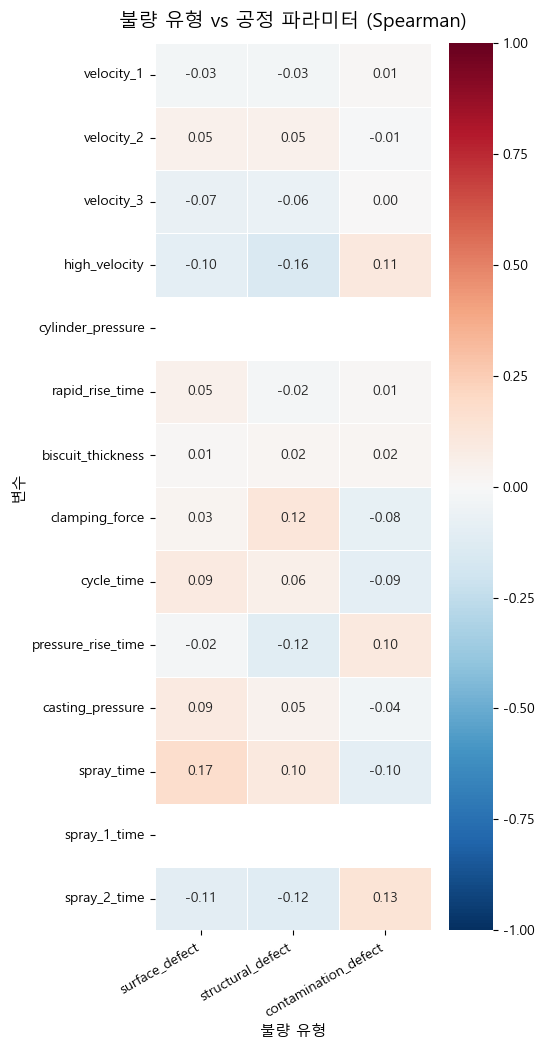

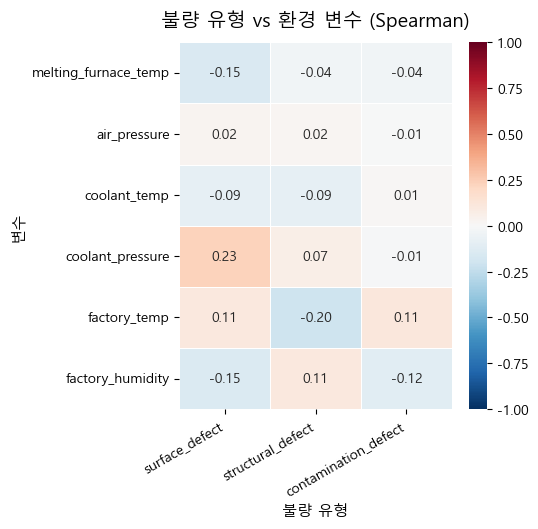

In [10]:
DEFECT_COLS = [
    'surface_defect',
    'structural_defect',
    'contamination_defect'
]

PROCESS_COLS = [
    'velocity_1', 'velocity_2', 'velocity_3', 'high_velocity',
    'cylinder_pressure', 'rapid_rise_time', 'biscuit_thickness',
    'clamping_force', 'cycle_time', 'pressure_rise_time',
    'casting_pressure', 'spray_time', 'spray_1_time', 'spray_2_time',
]

SENSOR_COLS = [
    'melting_furnace_temp', 'air_pressure', 'coolant_temp', 'coolant_pressure',
    'factory_temp', 'factory_humidity'
]

# 함수
def plot_corr_heatmap(df, defect_cols, feature_cols, title):
    corr = df[defect_cols + feature_cols].corr(method='spearman')
    corr_target = corr.loc[feature_cols, defect_cols]

    fig, ax = plt.subplots(
        figsize=(len(defect_cols) * 1.8, len(feature_cols) * 0.65 + 1.5)
    )

    sns.heatmap(
        corr_target,
        annot=True,
        fmt='.2f',
        cmap='RdBu_r',
        center=0,
        vmin=-1, vmax=1,
        linewidths=0.5,
        ax=ax
    )

    ax.set_title(title, fontsize=14, pad=12)
    ax.set_xlabel('불량 유형', fontsize=11)
    ax.set_ylabel('변수', fontsize=11)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

# 출력
plot_corr_heatmap(df_original_2, DEFECT_COLS, PROCESS_COLS, '불량 유형 vs 공정 파라미터 (Spearman)')
plot_corr_heatmap(df_original_2, DEFECT_COLS, SENSOR_COLS, '불량 유형 vs 환경 변수 (Spearman)')

# 2단계. 정규성 검정
Shapiro-Wilk

QQ plot

In [11]:
process_exclude_cols=["shot_key",
        "velocity_1_outlier_flag", 'velocity_3_outlier_flag','cylinder_pressure_outlier_flag', 
        'rapid_rise_time_outlier_flag','biscuit_thickness_outlier_flag', 'cycle_time_outlier_flag',
        'casting_pressure_outlier_flag', 'spray_time_outlier_flag','spray_1_time_outlier_flag']

sensor_exclude_cols = ["factory_temp_outlier_flag"]

In [12]:
# 정규성 검정 (Shapiro-Wilk)
def create_shapiro_summary(df, df_name, exclude_cols=None, alpha=0.05):
    """Shapiro-Wilk 정규성 검정"""
    print(f"\n{'='*80}")
    print(f"{df_name} 정규성 검정 (Shapiro-Wilk)")
    print(f"{'='*80}\n")
    
    #  exclude_cols에 속한 컬럼 제외
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')
    
    # 숫자형 컬럼만 선택
    df_copied = df_copied.select_dtypes(include='number')

    # 출력값 저장
    result_list = []
    
    # 각 컬럼별 정규성 검정
    for col in df_copied.columns:
        series = df_copied[col].dropna()
    
        # 정규성 확인: Shapiro-Wilk
        stat, p_value = shapiro(series)
    
        # H0: 정규성을 만족한다.
        # H1: 정규성을 불만족한다.
        if p_value > alpha:
            result = "정규성 만족"
        else:
            result = "정규성 불만족"

        # 출력값
        result_list.append([
            col, 
            stat, 
            p_value, 
            result])
    
    # 출력화면
    shapiro_df = pd.DataFrame(
        result_list, 
        columns=[
            "변수명", 
            "Shapiro 통계량", 
            "p-value", 
            "판정"
        ]
    ).set_index("변수명")
    
    display(shapiro_df)
    
    return shapiro_df

In [13]:
process_shapiro = create_shapiro_summary(
    df_process_2,
    "process",
    exclude_cols=process_exclude_cols
)
sensor_shapiro = create_shapiro_summary(
    df_sensor_2,
    "sensor",
    exclude_cols = sensor_exclude_cols
)
defects_shapiro = create_shapiro_summary(
    df_defects_2,
    "defects"
)


process 정규성 검정 (Shapiro-Wilk)



,Shapiro 통계량,p-value,판정
변수명,,,
velocity_1,0.926411,1.240283e-37,정규성 불만족
velocity_2,0.969190,3.757826e-26,정규성 불만족
velocity_3,0.985676,7.333695e-18,정규성 불만족
high_velocity,0.648671,9.326014e-64,정규성 불만족
cylinder_pressure,1.000000,1.000000e+00,정규성 만족
rapid_rise_time,0.760207,1.015670e-56,정규성 불만족
biscuit_thickness,0.951757,8.619553e-32,정규성 불만족
clamping_force,0.891286,1.720679e-43,정규성 불만족
cycle_time,0.836810,4.671696e-50,정규성 불만족



sensor 정규성 검정 (Shapiro-Wilk)



,Shapiro 통계량,p-value,판정
변수명,,,
melting_furnace_temp,0.973086,1.449105e-24,정규성 불만족
air_pressure,0.943995,8.517212e-34,정규성 불만족
coolant_temp,0.971870,4.450284e-25,정규성 불만족
coolant_pressure,0.881055,6.652185e-45,정규성 불만족
factory_temp,0.780887,4.042500e-55,정규성 불만족
factory_humidity,0.863516,4.142469e-47,정규성 불만족



defects 정규성 검정 (Shapiro-Wilk)



,Shapiro 통계량,p-value,판정
변수명,,,
surface_defect,0.248609,5.050891e-79,정규성 불만족
structural_defect,0.524135,1.196218e-69,정규성 불만족
contamination_defect,0.046663,3.784420e-84,정규성 불만족


In [14]:
# 테이블(데이터프레임)의 컬럼들로 QQ plot 한 번에 출력
def plot_qq_table(df, title=None, exclude_cols=None):
    
    # exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')

    # 숫자형 컬럼 전체 선택
    cols = df_copied.select_dtypes(include='number').columns.tolist()
    
    fig, axes = plt.subplots(4, 4, figsize=(15, 15))
    axes = axes.flatten()
    
    for i, col in enumerate(cols[:16]):
        series = df_copied[col].dropna()
        # Q-Q plot
        stats.probplot(series, dist="norm", plot=axes[i])
        axes[i].set_title(col)
    
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    if title:
        fig.suptitle(title, y=1.02)
    
    plt.tight_layout()
    plt.show()

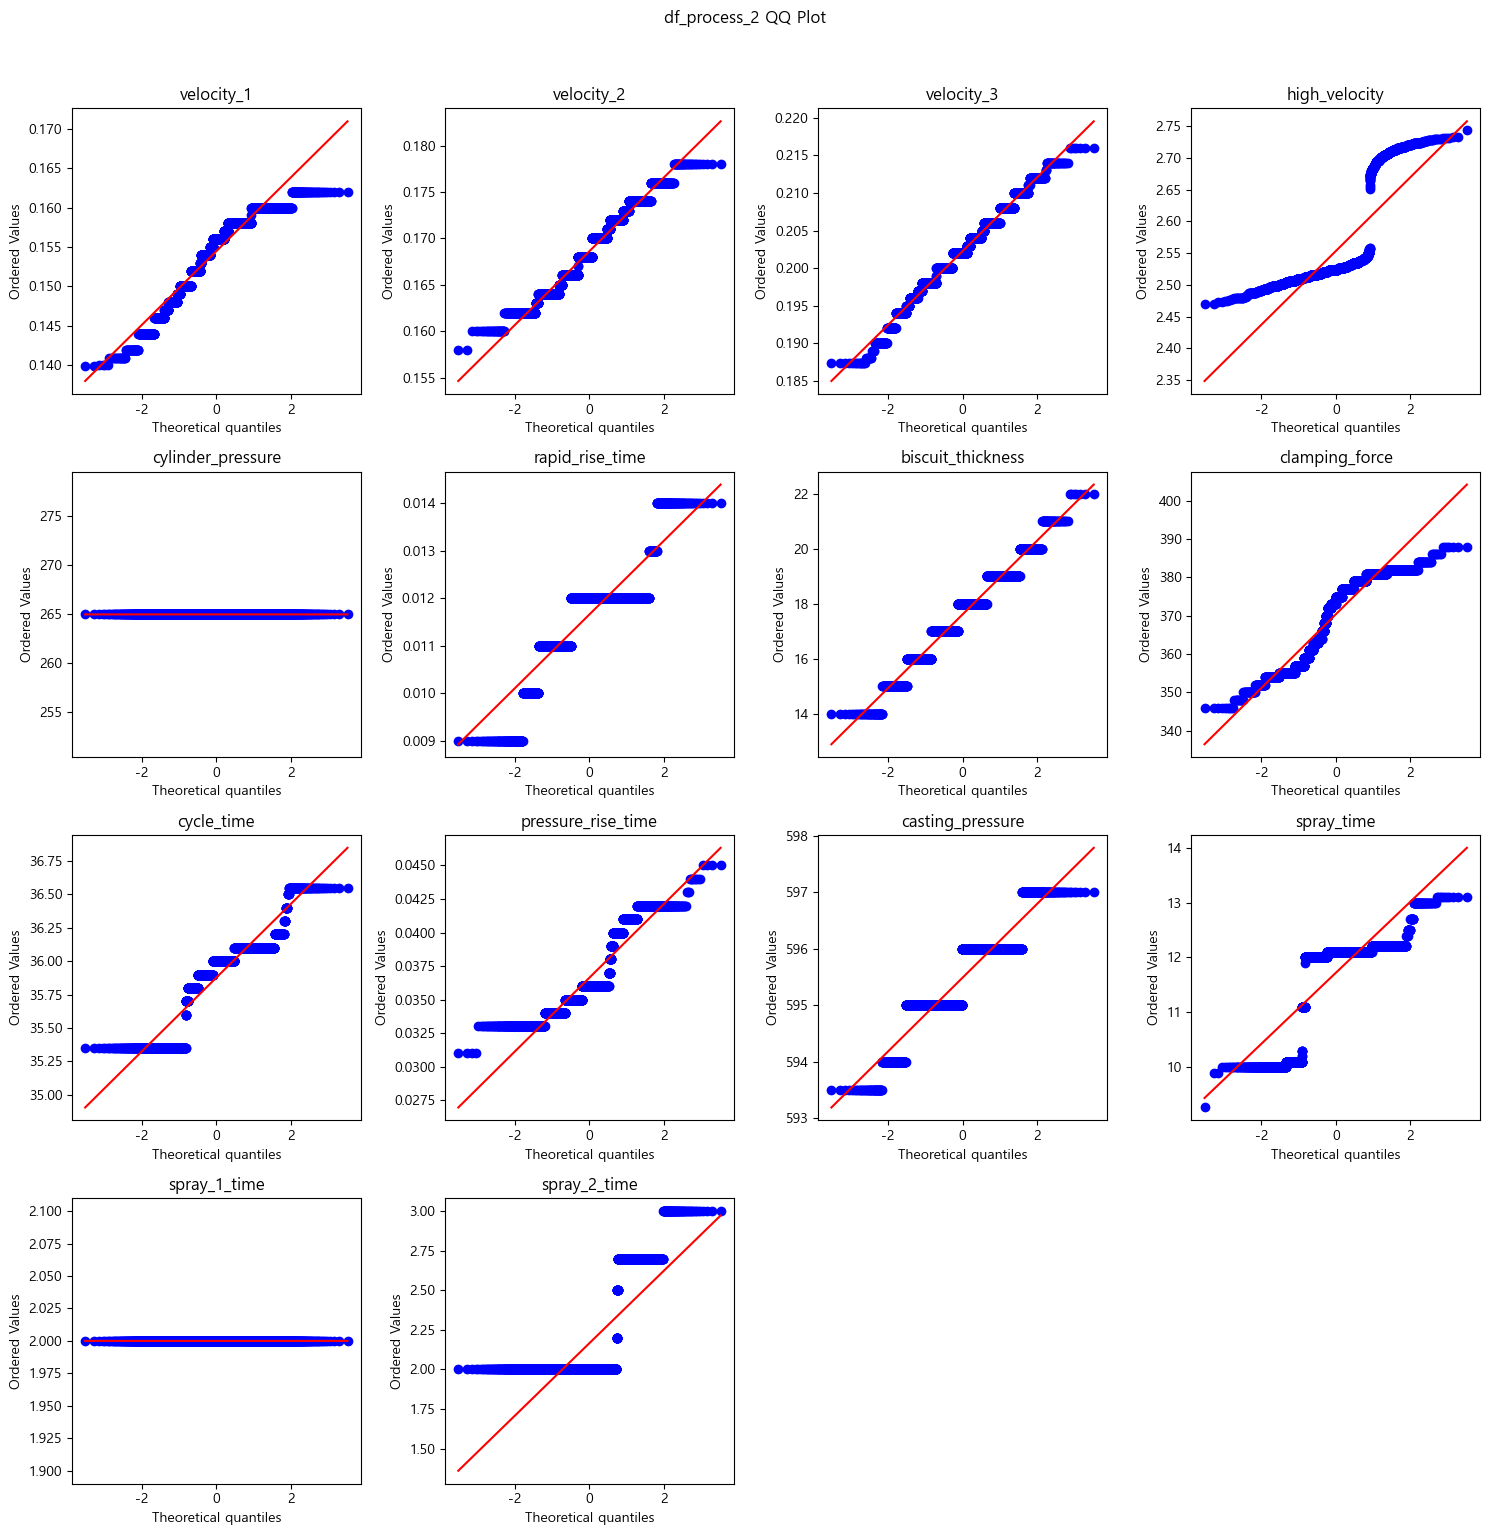

In [15]:
plot_qq_table(df_process_2, 
                title="df_process_2 QQ Plot",
                exclude_cols=process_exclude_cols
    )

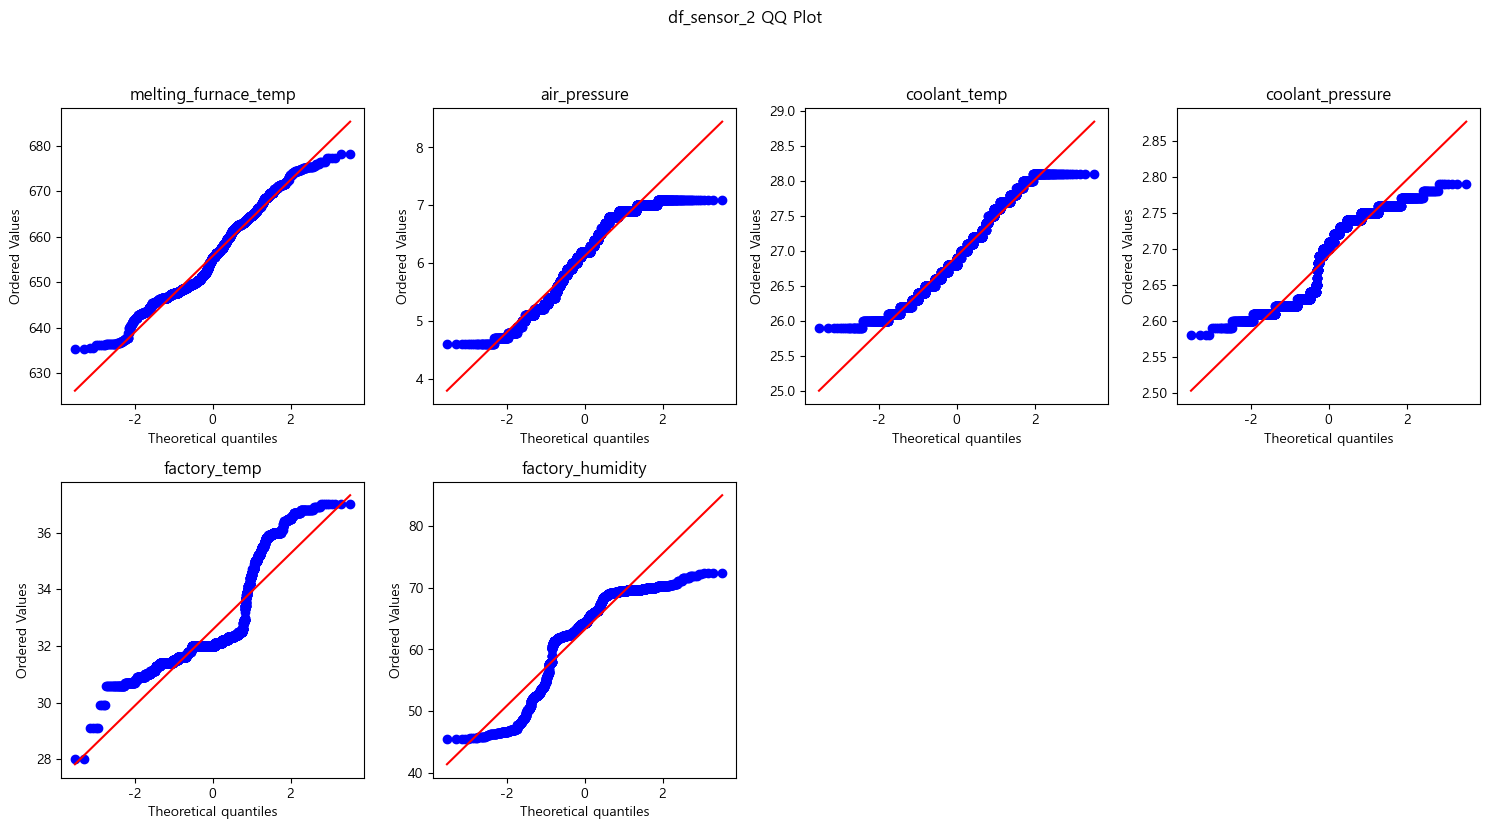

In [16]:
plot_qq_table(df_sensor_2, 
                title="df_sensor_2 QQ Plot", 
                exclude_cols = sensor_exclude_cols)

# 3단계. 등분산성 검정

In [17]:
# 기억한게 맞은건지 확인하는 용도
# from scipy.stats import levene

# def run_levene(df, col, target_col):
    
#     group_0 = df[df[target_col] == 0][col].dropna()
#     group_1 = df[df[target_col] == 1][col].dropna()
    
#     stat, p_value = levene(group_0, group_1)
#     print(f"{col} -> Levene 통계량: {stat:.4f}, p-value: {p_value:.4f}")
    
#     return stat, p_value

In [18]:
from scipy.stats import levene
import pandas as pd

# 등분산성 검정 (Levene test)
def create_levene_summary(features_df, defects_df, target_col, df_name, exclude_cols=None, alpha=0.05):
    """등분산성 검정 (Levene test)"""
    print(f"\n{'='*80}")
    print(f"{df_name} 등분산성 검정 (Levene test) - 기준: {target_col}")
    print(f"{'='*80}\n")
    
    # exclude_cols에 속한 컬럼 제외
    df_copied = features_df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')

        
    # 숫자형 컬럼만 선택
    df_copied = df_copied.select_dtypes(include='number')    
    
    # 타깃 (index 맞춤)
    target_series = defects_df[target_col]

    # 출력값 저장
    result_list = []
    
    # 각 컬럼별 등분산성 검정
    for col in df_copied.columns:
        group_0 = df_copied[target_series == 0][col].dropna()
        group_1 = df_copied[target_series == 1][col].dropna()
    
        # 등분산성 검정: levene
        stat, p_value = levene(group_0, group_1)

        # H0: 두 그룹의 분산이 같다 (등분산)
        # H1: 두 그룹의 분산이 다르다 (이분산)
        if p_value > alpha:
            result = "등분산 가정 가능"
        else:
            result = "등분산 가정 불가"

        # 출력 값
        result_list.append([
            col, 
            stat, 
            p_value, 
            result
        ]
    )
    
    # 출력화면
    levene_df = pd.DataFrame(
        result_list,
        columns=[
            "변수명", 
            "Levene 통계량", 
            "p-value", 
            "판정"
        ]
    ).set_index("변수명")
    
    display(levene_df)
    
    return levene_df

In [19]:
process_levene_surface = create_levene_summary(
    df_process_2,
    df_defects_2,
    "surface_defect",
    "df_process_2",
    exclude_cols = process_exclude_cols
)
process_levene_surface = create_levene_summary(
    df_process_2,
    df_defects_2,
    "structural_defect",
    "df_process_2",
    exclude_cols=process_exclude_cols
)
process_levene_surface = create_levene_summary(
    df_process_2,
    df_defects_2,
    "contamination_defect",
    "df_process_2",
    exclude_cols=process_exclude_cols
)


df_process_2 등분산성 검정 (Levene test) - 기준: surface_defect



,Levene 통계량,p-value,판정
변수명,,,
velocity_1,0.061166,8.046774e-01,등분산 가정 가능
velocity_2,0.022568,8.805948e-01,등분산 가정 가능
velocity_3,0.851463,3.562058e-01,등분산 가정 가능
high_velocity,25.965999,3.668546e-07,등분산 가정 불가
cylinder_pressure,NaN,NaN,등분산 가정 불가
rapid_rise_time,2.032700,1.540408e-01,등분산 가정 가능
biscuit_thickness,0.018153,8.928319e-01,등분산 가정 가능
clamping_force,70.291546,7.455310e-17,등분산 가정 불가
cycle_time,65.318928,8.827915e-16,등분산 가정 불가



df_process_2 등분산성 검정 (Levene test) - 기준: structural_defect



,Levene 통계량,p-value,판정
변수명,,,
velocity_1,6.588676,1.030631e-02,등분산 가정 불가
velocity_2,1.144535,2.847738e-01,등분산 가정 가능
velocity_3,0.810345,3.680835e-01,등분산 가정 가능
high_velocity,208.203514,7.973080e-46,등분산 가정 불가
cylinder_pressure,NaN,NaN,등분산 가정 불가
rapid_rise_time,2.452695,1.174184e-01,등분산 가정 가능
biscuit_thickness,0.582001,4.455832e-01,등분산 가정 가능
clamping_force,144.993082,1.022507e-32,등분산 가정 불가
cycle_time,45.780487,1.556728e-11,등분산 가정 불가



df_process_2 등분산성 검정 (Levene test) - 기준: contamination_defect



,Levene 통계량,p-value,판정
변수명,,,
velocity_1,1.790698,0.180933,등분산 가정 가능
velocity_2,0.532018,0.465811,등분산 가정 가능
velocity_3,0.004376,0.947260,등분산 가정 가능
high_velocity,4.145677,0.041820,등분산 가정 불가
cylinder_pressure,NaN,NaN,등분산 가정 불가
rapid_rise_time,0.392733,0.530909,등분산 가정 가능
biscuit_thickness,0.324459,0.568978,등분산 가정 가능
clamping_force,10.904523,0.000969,등분산 가정 불가
cycle_time,7.729081,0.005464,등분산 가정 불가


In [20]:
sensor_levene_surface = create_levene_summary(
    df_sensor_2,
    df_defects_2,
    "surface_defect",
    "df_sensor_2",
    exclude_cols=sensor_exclude_cols
)

sensor_levene_surface = create_levene_summary(
    df_sensor_2,
    df_defects_2,
    "structural_defect",
    "df_sensor_2",
    exclude_cols=sensor_exclude_cols
)

sensor_levene_surface = create_levene_summary(
    df_sensor_2,
    df_defects_2,
    "contamination_defect",
    "df_sensor_2",
    exclude_cols=sensor_exclude_cols
)


df_sensor_2 등분산성 검정 (Levene test) - 기준: surface_defect



,Levene 통계량,p-value,판정
변수명,,,
melting_furnace_temp,65.574167,7.774936e-16,등분산 가정 불가
air_pressure,75.345291,6.084221e-18,등분산 가정 불가
coolant_temp,192.865009,1.144082e-42,등분산 가정 불가
coolant_pressure,355.205736,2.304949e-75,등분산 가정 불가
factory_temp,50.247877,1.647294e-12,등분산 가정 불가
factory_humidity,132.681439,3.928359e-30,등분산 가정 불가



df_sensor_2 등분산성 검정 (Levene test) - 기준: structural_defect



,Levene 통계량,p-value,판정
변수명,,,
melting_furnace_temp,12.164641,4.933525e-04,등분산 가정 불가
air_pressure,1.067727,3.015346e-01,등분산 가정 가능
coolant_temp,14.275245,1.606951e-04,등분산 가정 불가
coolant_pressure,4.739183,2.955317e-02,등분산 가정 불가
factory_temp,116.471853,1.032387e-26,등분산 가정 불가
factory_humidity,175.993494,3.533579e-39,등분산 가정 불가



df_sensor_2 등분산성 검정 (Levene test) - 기준: contamination_defect



,Levene 통계량,p-value,판정
변수명,,,
melting_furnace_temp,1.526687,2.166976e-01,등분산 가정 가능
air_pressure,3.738271,5.326421e-02,등분산 가정 가능
coolant_temp,10.270201,1.364746e-03,등분산 가정 불가
coolant_pressure,40.677985,2.042922e-10,등분산 가정 불가
factory_temp,4.190950,4.071874e-02,등분산 가정 불가
factory_humidity,7.819280,5.198870e-03,등분산 가정 불가


상관관계 분석

# 4단계. 실제 집단 차이 검정


A. 타깃이 0/1 이진 변수
- 정규성 어느 정도 괜찮고 평균 비교 목적이면 → Welch t-test → Cohen's d
- 분포가 많이 찌그러졌거나 이상치 영향이 크면 → Mann-Whitney U → rank-
- 효과 크기

B. 타깃이 3개 이상 다중 범주
- 정규성/등분산성 괜찮으면 → ANOVA → Tukey → 효과크기: eta squared(η²) or omega squared(ω²)
- 등분산성 안 맞으면 → Welch ANOVA → Games-Howell → 효과크기: eta squared(η²) or omega squared(ω²)
- 비모수로 가면 → Kruskal-Wallis → Dunn test (보정 포함) → 효과크기: epsilon squared(ε²)

## A. 타깃이 0/1 이진 변수

### welch-t 검정

In [21]:
def cohens_d_ind(group1, group2): # 독립표본 d(합동표준편차 사용)
    """Cohen's d — 독립표본: d = |x̄₁ - x̄₂| / s_pooled"""
    n1, n2 = len(group1), len(group2)
    var1 = np.var(group1, ddof=1)
    var2 = np.var(group2, ddof=1)
    s_pooled = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2)) # 합동 분산 
    return abs(np.mean(group1) - np.mean(group2)) / s_pooled

In [22]:
from scipy.stats import ttest_ind

# Welch t-test 검정 + Cohen's d 효과크기
def create_welch_summary(features_df, defects_df, target_col, df_name, exclude_cols=None, alpha=0.05):
    """Welch t-검정 및 효과크기"""
    print(f"\n{'='*80}")
    print(f"{df_name} 실제 집단 차이 검정 (Welch t-test) - 기준: {target_col}")
    print(f"{'='*80}\n")
    
    # exclude_cols에 속한 컬럼 제외
    df_copied = features_df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')
    
    # 숫자형 컬럼만 선택
    df_copied = df_copied.select_dtypes(include='number')
    
    # 타깃 (index 맞춤)
    target_series = defects_df[target_col].reindex(df_copied.index)

    # 출력값 저장
    result_list = []
    
    for col in df_copied.columns:
        group_0 = df_copied.loc[target_series == 0, col].dropna()
        group_1 = df_copied.loc[target_series == 1, col].dropna()
    
        # 통계검정: Welch t-검정 (등분산 가정 X)
        # 양측검정 (two-sided)
        t_stat, p_value = ttest_ind(group_0, group_1, equal_var=False, alternative='two-sided')
        
        # 효과크기: Cohen's d
        cohen_d = cohens_d_ind(group_0, group_1)
    
        # 가설검정 판정
        # alpha 변환 가능
        # 귀무가설(H0): 두 집단의 평균이 같다. (μ0 = μ1)
        # 대립가설(H1): 두 집단의 평균이 다르다. (μ0 ≠ μ1)
        if p_value >= alpha:
            result = "유의한 차이 없음 ㅠㅠ"
        else:
            result = "유의한 차이 있음!!!!!"

        # 효과크기 판정 = 기준은 유동적
        if abs(cohen_d) < 0.1:
            effect = "매우 작은 효과"
        elif abs(cohen_d) < 0.3:
            effect= "작은 효과"
        elif abs(cohen_d) < 0.5:
            effect = "중간 효과"
        else:
            effect = "큰 효과"
        
        # 출력값
        result_list.append([
            col,
            len(group_0),
            len(group_1),
            t_stat,
            p_value,
            cohen_d,
            result,
            effect
        ])


    # 출력화면
    welch_df = pd.DataFrame(
        result_list,
        columns=[
            "변수명",
            "해당 불량이 없는 샷",
            "해당 불량이 있는 샷",
            "t 통계량", 
            "p-value", 
            "Cohen's d", 
            "판정",
            "효과크기 판정"
        ]
    ).set_index("변수명")
    
    display(welch_df)
    
    return welch_df

In [23]:
process_welch_surface = create_welch_summary(
    df_process_2,
    df_defects_2,
    "surface_defect",
    "df_process_2",
    exclude_cols=process_exclude_cols
)
process_welch_surface = create_welch_summary(
    df_process_2,
    df_defects_2,
    "structural_defect",
    "df_process_2",
    exclude_cols=process_exclude_cols
)
process_welch_surface = create_welch_summary(
    df_process_2,
    df_defects_2,
    "contamination_defect",
    "df_process_2",
    exclude_cols=process_exclude_cols
)


df_process_2 실제 집단 차이 검정 (Welch t-test) - 기준: surface_defect



,해당 불량이 없는 샷,해당 불량이 있는 샷,t 통계량,p-value,Cohen's d,판정,효과크기 판정
변수명,,,,,,,
velocity_1,3132,196,1.325357,1.864212e-01,0.096141,유의한 차이 없음 ㅠㅠ,매우 작은 효과
velocity_2,3132,196,-3.194985,1.603879e-03,0.236931,유의한 차이 있음!!!!!,작은 효과
velocity_3,3132,196,4.649358,5.675145e-06,0.317247,유의한 차이 있음!!!!!,중간 효과
high_velocity,3132,196,8.940431,5.311591e-17,0.398087,유의한 차이 있음!!!!!,중간 효과
cylinder_pressure,3132,196,NaN,NaN,NaN,유의한 차이 있음!!!!!,큰 효과
rapid_rise_time,3132,196,-3.629522,3.515403e-04,0.248289,유의한 차이 있음!!!!!,작은 효과
biscuit_thickness,3132,196,-0.021505,9.828624e-01,0.001526,유의한 차이 없음 ㅠㅠ,매우 작은 효과
clamping_force,3132,196,-4.113472,5.406900e-05,0.253777,유의한 차이 있음!!!!!,작은 효과
cycle_time,3132,196,-9.520574,6.908780e-19,0.406019,유의한 차이 있음!!!!!,중간 효과



df_process_2 실제 집단 차이 검정 (Welch t-test) - 기준: structural_defect



,해당 불량이 없는 샷,해당 불량이 있는 샷,t 통계량,p-value,Cohen's d,판정,효과크기 판정
변수명,,,,,,,
velocity_1,2550,778,1.989517,4.686420e-02,0.083697,유의한 차이 있음!!!!!,매우 작은 효과
velocity_2,2550,778,-2.735110,6.322372e-03,0.112686,유의한 차이 있음!!!!!,작은 효과
velocity_3,2550,778,3.928846,8.981080e-05,0.159191,유의한 차이 있음!!!!!,작은 효과
high_velocity,2550,778,21.679671,1.473280e-97,0.563524,유의한 차이 있음!!!!!,큰 효과
cylinder_pressure,2550,778,NaN,NaN,NaN,유의한 차이 있음!!!!!,큰 효과
rapid_rise_time,2550,778,1.627489,1.038946e-01,0.069693,유의한 차이 없음 ㅠㅠ,매우 작은 효과
biscuit_thickness,2550,778,-0.688227,4.914355e-01,0.028395,유의한 차이 없음 ㅠㅠ,매우 작은 효과
clamping_force,2550,778,-9.763388,6.687545e-22,0.357183,유의한 차이 있음!!!!!,중간 효과
cycle_time,2550,778,-3.662100,2.581565e-04,0.131621,유의한 차이 있음!!!!!,작은 효과



df_process_2 실제 집단 차이 검정 (Welch t-test) - 기준: contamination_defect



,해당 불량이 없는 샷,해당 불량이 있는 샷,t 통계량,p-value,Cohen's d,판정,효과크기 판정
변수명,,,,,,,
velocity_1,3309,19,-1.126143,2.746093e-01,0.197105,유의한 차이 없음 ㅠㅠ,작은 효과
velocity_2,3309,19,0.703599,4.905523e-01,0.141735,유의한 차이 없음 ㅠㅠ,작은 효과
velocity_3,3309,19,-0.415767,6.824425e-01,0.098201,유의한 차이 없음 ㅠㅠ,매우 작은 효과
high_velocity,3309,19,-44.076826,2.712992e-24,2.134595,유의한 차이 있음!!!!!,큰 효과
cylinder_pressure,3309,19,NaN,NaN,NaN,유의한 차이 있음!!!!!,큰 효과
rapid_rise_time,3309,19,-0.497843,6.245805e-01,0.146329,유의한 차이 없음 ㅠㅠ,작은 효과
biscuit_thickness,3309,19,-1.239596,2.308661e-01,0.285964,유의한 차이 없음 ㅠㅠ,작은 효과
clamping_force,3309,19,11.463953,5.416329e-10,1.195075,유의한 차이 있음!!!!!,큰 효과
cycle_time,3309,19,7.360011,7.245621e-07,1.561235,유의한 차이 있음!!!!!,큰 효과


In [24]:
sensor_welch_surface = create_welch_summary(
    df_sensor_2,
    df_defects_2,
    "surface_defect",
    "df_sensor_2",
    exclude_cols=sensor_exclude_cols
)
sensor_welch_surface = create_welch_summary(
    df_sensor_2,
    df_defects_2,
    "structural_defect",
    "df_sensor_2",
    exclude_cols=sensor_exclude_cols
)
sensor_welch_surface = create_welch_summary(
    df_sensor_2,
    df_defects_2,
    "contamination_defect",
    "df_sensor_2",
    exclude_cols=sensor_exclude_cols
)


df_sensor_2 실제 집단 차이 검정 (Welch t-test) - 기준: surface_defect



,해당 불량이 없는 샷,해당 불량이 있는 샷,t 통계량,p-value,Cohen's d,판정,효과크기 판정
변수명,,,,,,,
melting_furnace_temp,3132,196,10.923136,8.454413e-23,0.632707,유의한 차이 있음!!!!!,큰 효과
air_pressure,3132,196,-3.982873,8.784878e-05,0.189592,유의한 차이 있음!!!!!,작은 효과
coolant_temp,3132,196,12.242019,1.868335e-29,0.407622,유의한 차이 있음!!!!!,중간 효과
coolant_pressure,3132,196,-35.071254,7.647272e-142,1.005125,유의한 차이 있음!!!!!,큰 효과
factory_temp,3132,196,3.498679,5.353129e-04,0.138736,유의한 차이 있음!!!!!,작은 효과
factory_humidity,3132,196,5.212458,3.172380e-07,0.186853,유의한 차이 있음!!!!!,작은 효과



df_sensor_2 실제 집단 차이 검정 (Welch t-test) - 기준: structural_defect



,해당 불량이 없는 샷,해당 불량이 있는 샷,t 통계량,p-value,Cohen's d,판정,효과크기 판정
변수명,,,,,,,
melting_furnace_temp,2550,778,1.915319,5.566040e-02,0.075586,유의한 차이 없음 ㅠㅠ,매우 작은 효과
air_pressure,2550,778,-1.293262,1.961524e-01,0.052975,유의한 차이 없음 ㅠㅠ,매우 작은 효과
coolant_temp,2550,778,4.761466,2.156420e-06,0.204759,유의한 차이 있음!!!!!,작은 효과
coolant_pressure,2550,778,-2.893423,3.878602e-03,0.123095,유의한 차이 있음!!!!!,작은 효과
factory_temp,2550,778,17.708825,6.644375e-66,0.548275,유의한 차이 있음!!!!!,큰 효과
factory_humidity,2550,778,-13.626753,8.619911e-41,0.414841,유의한 차이 있음!!!!!,중간 효과



df_sensor_2 실제 집단 차이 검정 (Welch t-test) - 기준: contamination_defect



,해당 불량이 없는 샷,해당 불량이 있는 샷,t 통계량,p-value,Cohen's d,판정,효과크기 판정
변수명,,,,,,,
melting_furnace_temp,3309,19,1.864063,7.853109e-02,0.442472,유의한 차이 없음 ㅠㅠ,중간 효과
air_pressure,3309,19,0.262318,7.959972e-01,0.046189,유의한 차이 없음 ㅠㅠ,매우 작은 효과
coolant_temp,3309,19,-0.681303,5.040675e-01,0.091800,유의한 차이 없음 ㅠㅠ,매우 작은 효과
coolant_pressure,3309,19,-2.548387,1.811960e-02,0.136076,유의한 차이 있음!!!!!,작은 효과
factory_temp,3309,19,-26.377092,8.318704e-17,2.222640,유의한 차이 있음!!!!!,큰 효과
factory_humidity,3309,19,19.832692,4.120622e-14,2.221315,유의한 차이 있음!!!!!,큰 효과


### Mann-Whitney U 검정

In [25]:
from scipy.stats import mannwhitneyu
import pingouin as pg

# Mann-Whitney U 검정 + rank-biserial 효과크기
def create_mannwhitney_summary(features_df, defects_df, target_col, df_name, exclude_cols=None, alpha=0.05):
    """mannwhitney u-검정 및 효과크기"""
    print(f"\n{'='*80}")
    print(f"{df_name} 실제 집단 차이 검정 (Mann-Whitney U) - 기준: {target_col}")
    print(f"{'='*80}\n")

    # exclude_cols에 속한 컬럼 제외
    df_copied = features_df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')

    # 숫자형 컬럼만 선택
    df_copied = df_copied.select_dtypes(include='number')
    
    # 타깃 (index 맞춤)
    target_series = defects_df[target_col].reindex(df_copied.index)

    # 출력값 저장
    result_list = []
    
    for col in df_copied.columns:
        group_0 = df_copied.loc[target_series == 0, col].dropna()
        group_1 = df_copied.loc[target_series == 1, col].dropna()
    
        # 통계 검정: Mann-Whitney U (비모수, 순위 기반)
        # group_1을 먼저 넣어, rank-biserial 양수면 1그룹(불량=1)이 더 큰 경향
        # 양측검정 (two-sided)   
        u_stat, p_value = mannwhitneyu(group_1, group_0, alternative='two-sided')
        
        # 효과크기: rank-biserial correlation
        out = pg.mwu(group_1, group_0, alternative='two-sided')
        # u_stat = out["U-val"].values[0] # u_stat 있음
        # p_value = out["p-val"].values[0] # p_value 있음
        rbc = out["RBC"].values[0] # rbc 
        
        # 가설검정 판정
        # alpha 변환 가능
        # 귀무가설(H0): 두 집단의 분포가 같다. (순위가 비슷하다)  → 차이가 없다
        # 대립가설(H1): 두 집단의 분포가 다르다. (순위가 다르다) → 차이가 있다
        if p_value >= alpha:
            result = "유의한 차이 없음 ㅠㅠ"
        else:
            result = "유의한 차이 있음!!!!!"

        # 효과크기 판정 = 기준은 유동적
        if abs(rbc) < 0.1:
            effect = "매우 작은 효과"
        elif abs(rbc) < 0.3:
            effect= "작은 효과"
        elif abs(rbc) < 0.5:
            effect = "중간 효과"
        else:
            effect = "큰 효과"
        
        # 출력값
        result_list.append([
            col, 
            len(group_0),
            len(group_1),
            u_stat, 
            p_value, 
            rbc, 
            result, 
            effect
        ])
    
    # 출력화면
    mannwhitney_df = pd.DataFrame(
        result_list,
        columns=[
            "변수명", 
                "해당 불량이 없는 샷",
                "해당 불량이 있는 샷",
                "U 통계량", 
                "p-value", 
                "rank-biserial", 
                "판정",
                "효과크기 판정"
            ]
    ).set_index("변수명")

    display(mannwhitney_df)
    
    return mannwhitney_df

In [26]:
process_welch_surface = create_mannwhitney_summary(
    df_process_2,
    df_defects_2,
    "surface_defect",
    "df_process_2",
    exclude_cols=process_exclude_cols,
)
process_welch_surface = create_mannwhitney_summary(
    df_process_2,
    df_defects_2,
    "structural_defect",
    "df_process_2",
    exclude_cols=process_exclude_cols,
)
process_welch_surface = create_mannwhitney_summary(
    df_process_2,
    df_defects_2,
    "contamination_defect",
    "df_process_2",
    exclude_cols=process_exclude_cols,
)


df_process_2 실제 집단 차이 검정 (Mann-Whitney U) - 기준: surface_defect



,해당 불량이 없는 샷,해당 불량이 있는 샷,U 통계량,p-value,rank-biserial,판정,효과크기 판정
변수명,,,,,,,
velocity_1,3132,196,285704.5,1.009793e-01,-0.069172,유의한 차이 없음 ㅠㅠ,매우 작은 효과
velocity_2,3132,196,347632.0,1.682775e-03,0.132588,유의한 차이 있음!!!!!,작은 효과
velocity_3,3132,196,252974.5,3.179453e-05,-0.175807,유의한 차이 있음!!!!!,작은 효과
high_velocity,3132,196,234790.0,3.203845e-08,-0.235052,유의한 차이 있음!!!!!,작은 효과
cylinder_pressure,3132,196,306936.0,1.000000e+00,0.000000,유의한 차이 없음 ㅠㅠ,매우 작은 효과
rapid_rise_time,3132,196,338555.5,4.527888e-03,0.103017,유의한 차이 있음!!!!!,작은 효과
biscuit_thickness,3132,196,313703.0,5.946449e-01,0.022047,유의한 차이 없음 ㅠㅠ,매우 작은 효과
clamping_force,3132,196,327658.0,1.111398e-01,0.067512,유의한 차이 없음 ㅠㅠ,매우 작은 효과
cycle_time,3132,196,372130.0,3.383432e-07,0.212403,유의한 차이 있음!!!!!,작은 효과



df_process_2 실제 집단 차이 검정 (Mann-Whitney U) - 기준: structural_defect



,해당 불량이 없는 샷,해당 불량이 있는 샷,U 통계량,p-value,rank-biserial,판정,효과크기 판정
변수명,,,,,,,
velocity_1,2550,778,951984.5,8.591068e-02,-0.040290,유의한 차이 없음 ㅠㅠ,매우 작은 효과
velocity_2,2550,778,1060403.5,3.291566e-03,0.069009,유의한 차이 있음!!!!!,매우 작은 효과
velocity_3,2550,778,905367.5,2.046945e-04,-0.087285,유의한 차이 있음!!!!!,매우 작은 효과
high_velocity,2550,778,780578.5,2.018536e-19,-0.213087,유의한 차이 있음!!!!!,작은 효과
cylinder_pressure,2550,778,991950.0,1.000000e+00,0.000000,유의한 차이 없음 ㅠㅠ,매우 작은 효과
rapid_rise_time,2550,778,970366.0,2.810628e-01,-0.021759,유의한 차이 없음 ㅠㅠ,매우 작은 효과
biscuit_thickness,2550,778,1014619.0,3.213833e-01,0.022853,유의한 차이 없음 ㅠㅠ,매우 작은 효과
clamping_force,2550,778,1151087.0,1.006101e-11,0.160428,유의한 차이 있음!!!!!,작은 효과
cycle_time,2550,778,1065786.0,1.311477e-03,0.074435,유의한 차이 있음!!!!!,매우 작은 효과



df_process_2 실제 집단 차이 검정 (Mann-Whitney U) - 기준: contamination_defect



,해당 불량이 없는 샷,해당 불량이 있는 샷,U 통계량,p-value,rank-biserial,판정,효과크기 판정
변수명,,,,,,,
velocity_1,3309,19,33784.5,5.707785e-01,0.074724,유의한 차이 없음 ㅠㅠ,매우 작은 효과
velocity_2,3309,19,28886.0,5.386924e-01,-0.081103,유의한 차이 없음 ㅠㅠ,매우 작은 효과
velocity_3,3309,19,32000.0,8.919228e-01,0.017957,유의한 차이 없음 ㅠㅠ,매우 작은 효과
high_velocity,3309,19,57303.5,5.809452e-10,0.822891,유의한 차이 있음!!!!!,큰 효과
cylinder_pressure,3309,19,31435.5,1.000000e+00,0.000000,유의한 차이 없음 ㅠㅠ,매우 작은 효과
rapid_rise_time,3309,19,33606.0,5.426658e-01,0.069046,유의한 차이 없음 ㅠㅠ,매우 작은 효과
biscuit_thickness,3309,19,36887.0,1.804177e-01,0.173419,유의한 차이 없음 ㅠㅠ,작은 효과
clamping_force,3309,19,11102.5,1.036697e-06,-0.646816,유의한 차이 있음!!!!!,큰 효과
cycle_time,3309,19,9216.5,5.573815e-08,-0.706812,유의한 차이 있음!!!!!,큰 효과


In [27]:
process_welch_surface = create_mannwhitney_summary(
    df_sensor_2,
    df_defects_2,
    "surface_defect",
    "df_sensor_2",
    exclude_cols=process_exclude_cols,
)
process_welch_surface = create_mannwhitney_summary(
    df_sensor_2,
    df_defects_2,
    "structural_defect",
    "df_sensor_2",
    exclude_cols=process_exclude_cols,
)
process_welch_surface = create_mannwhitney_summary(
    df_sensor_2,
    df_defects_2,
    "contamination_defect",
    "df_sensor_2",
    exclude_cols=process_exclude_cols,
)


df_sensor_2 실제 집단 차이 검정 (Mann-Whitney U) - 기준: surface_defect



,해당 불량이 없는 샷,해당 불량이 있는 샷,U 통계량,p-value,rank-biserial,판정,효과크기 판정
변수명,,,,,,,
melting_furnace_temp,3132,196,192775.5,2.168383e-18,-0.371936,유의한 차이 있음!!!!!,중간 효과
air_pressure,3132,196,324882.5,1.683330e-01,0.058470,유의한 차이 없음 ㅠㅠ,매우 작은 효과
coolant_temp,3132,196,237277.0,8.932353e-08,-0.226950,유의한 차이 있음!!!!!,작은 효과
coolant_pressure,3132,196,481721.0,3.324749e-41,0.569451,유의한 차이 있음!!!!!,큰 효과
factory_temp,3132,196,387373.5,5.519633e-10,0.262066,유의한 차이 있음!!!!!,작은 효과
factory_humidity,3132,196,197727.5,5.784257e-17,-0.355802,유의한 차이 있음!!!!!,중간 효과
factory_temp_outlier_flag,3132,196,306740.0,7.241412e-01,-0.000639,유의한 차이 없음 ㅠㅠ,매우 작은 효과



df_sensor_2 실제 집단 차이 검정 (Mann-Whitney U) - 기준: structural_defect



,해당 불량이 없는 샷,해당 불량이 있는 샷,U 통계량,p-value,rank-biserial,판정,효과크기 판정
변수명,,,,,,,
melting_furnace_temp,2550,778,939142.0,2.438473e-02,-0.053237,유의한 차이 있음!!!!!,매우 작은 효과
air_pressure,2550,778,1023249.0,1.814032e-01,0.031553,유의한 차이 없음 ㅠㅠ,매우 작은 효과
coolant_temp,2550,778,870806.0,2.305228e-07,-0.122127,유의한 차이 있음!!!!!,작은 효과
coolant_pressure,2550,778,1085803.0,5.927115e-05,0.094615,유의한 차이 있음!!!!!,매우 작은 효과
factory_temp,2550,778,718408.0,8.419165e-32,-0.275762,유의한 차이 있음!!!!!,작은 효과
factory_humidity,2550,778,1138038.0,4.728284e-10,0.147274,유의한 차이 있음!!!!!,작은 효과
factory_temp_outlier_flag,2550,778,994500.0,1.046093e-02,0.002571,유의한 차이 있음!!!!!,매우 작은 효과



df_sensor_2 실제 집단 차이 검정 (Mann-Whitney U) - 기준: contamination_defect



,해당 불량이 없는 샷,해당 불량이 있는 샷,U 통계량,p-value,rank-biserial,판정,효과크기 판정
변수명,,,,,,,
melting_furnace_temp,3309,19,22734.5,3.721976e-02,-0.276789,유의한 차이 있음!!!!!,작은 효과
air_pressure,3309,19,29721.5,6.810689e-01,-0.054524,유의한 차이 없음 ㅠㅠ,매우 작은 효과
coolant_temp,3309,19,34390.5,4.785229e-01,0.094002,유의한 차이 없음 ㅠㅠ,매우 작은 효과
coolant_pressure,3309,19,29274.0,6.034799e-01,-0.068760,유의한 차이 없음 ㅠㅠ,매우 작은 효과
factory_temp,3309,19,58795.0,4.302898e-11,0.870338,유의한 차이 있음!!!!!,큰 효과
factory_humidity,3309,19,3409.5,1.927410e-11,-0.891540,유의한 차이 있음!!!!!,큰 효과
factory_temp_outlier_flag,3309,19,31416.5,9.168850e-01,-0.000604,유의한 차이 없음 ㅠㅠ,매우 작은 효과


---
일단 여기까지

# EDA 작성해보기

In [28]:
df_original_2.head()

,shot_key,velocity_1,velocity_2,velocity_3,high_velocity,cylinder_pressure,rapid_rise_time,biscuit_thickness,clamping_force,cycle_time,pressure_rise_time,casting_pressure,spray_time,spray_1_time,spray_2_time,velocity_1_outlier_flag,velocity_3_outlier_flag,cylinder_pressure_outlier_flag,rapid_rise_time_outlier_flag,biscuit_thickness_outlier_flag,cycle_time_outlier_flag,casting_pressure_outlier_flag,spray_time_outlier_flag,spray_1_time_outlier_flag,melting_furnace_temp,air_pressure,coolant_temp,coolant_pressure,factory_temp,factory_humidity,factory_temp_outlier_flag,surface_defect,structural_defect,contamination_defect
0,4207011_11,0.156,0.166,0.192,2.723,265,0.012,20,357,36.55,0.041,595.0,12.5,2.0,2.2,0,0,0,0,0,1,0,0,0,671.6,6.5,26.1,2.70,33.2,57.4,0,0,0,0
1,4208012_12,0.157,0.166,0.204,2.730,265,0.014,19,359,36.50,0.040,594.0,12.5,2.0,2.2,0,0,1,0,0,0,0,0,0,672.1,6.4,26.2,2.71,33.3,57.0,0,0,0,0
2,4209013_13,0.156,0.170,0.204,2.715,265,0.012,18,361,36.50,0.041,595.0,12.5,2.0,2.2,0,0,0,0,0,0,0,0,0,672.4,6.4,26.2,2.70,33.5,56.7,0,0,0,0
3,4210014_14,0.154,0.170,0.202,2.717,265,0.011,20,364,36.50,0.042,595.0,12.5,2.0,2.2,0,0,1,0,0,0,0,0,0,672.4,6.4,26.2,2.70,33.5,56.7,0,0,0,0
4,4211015_15,0.146,0.160,0.198,2.684,265,0.012,20,357,36.50,0.042,595.0,12.5,2.0,2.2,0,0,1,0,0,0,0,0,0,672.4,6.3,26.2,2.71,33.6,56.4,0,0,0,0


In [29]:
# 기술통계량 확인
df_original_2.describe()

,velocity_1,velocity_2,velocity_3,high_velocity,cylinder_pressure,rapid_rise_time,biscuit_thickness,clamping_force,cycle_time,pressure_rise_time,casting_pressure,spray_time,spray_1_time,spray_2_time,velocity_1_outlier_flag,velocity_3_outlier_flag,cylinder_pressure_outlier_flag,rapid_rise_time_outlier_flag,biscuit_thickness_outlier_flag,cycle_time_outlier_flag,casting_pressure_outlier_flag,spray_time_outlier_flag,spray_1_time_outlier_flag,melting_furnace_temp,air_pressure,coolant_temp,coolant_pressure,factory_temp,factory_humidity,factory_temp_outlier_flag,surface_defect,structural_defect,contamination_defect
count,3328.000000,3328.000000,3328.000000,3328.000000,3328.0,3328.000000,3328.000000,3328.000000,3328.000000,3328.000000,3328.000000,3328.000000,3328.0,3328.000000,3328.000000,3328.000000,3328.000000,3328.000000,3328.000000,3328.000000,3328.000000,3328.000000,3328.000000,3328.000000,3328.000000,3328.000000,3328.000000,3328.000000,3328.000000,3328.000000,3328.000000,3328.000000,3328.000000
mean,0.154473,0.168620,0.202256,2.553245,265.0,0.011660,17.610276,370.342548,35.876908,0.036638,595.487831,11.717777,2.0,2.166466,0.000601,0.004507,0.207031,0.036058,0.006911,0.229267,0.014724,0.000300,0.040865,655.703996,6.120583,26.923347,2.689742,32.572087,63.190775,0.000601,0.058894,0.233774,0.005709
std,0.004836,0.004023,0.004921,0.071882,0.0,0.000887,1.370777,10.160827,0.300762,0.002946,0.714245,0.817132,0.0,0.307934,0.024511,0.066994,0.405239,0.186462,0.082857,0.420424,0.120462,0.017334,0.198008,8.494439,0.677288,0.551408,0.056365,1.521800,6.631947,0.024511,0.235462,0.423294,0.075354
min,0.139961,0.158000,0.187391,2.470000,265.0,0.009000,14.000000,346.000000,35.350000,0.031000,593.500000,9.262077,2.0,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,635.300000,4.600000,25.900000,2.580000,28.003531,45.500000,0.000000,0.000000,0.000000,0.000000
25%,0.151500,0.166000,0.200000,2.514000,265.0,0.011000,17.000000,361.000000,35.800000,0.034000,595.000000,12.000000,2.0,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,648.700000,5.600000,26.500000,2.630000,31.600000,61.800000,0.000000,0.000000,0.000000,0.000000
50%,0.156000,0.168000,0.202000,2.524000,265.0,0.012000,18.000000,375.000000,36.000000,0.036000,596.000000,12.100000,2.0,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,655.400000,6.200000,26.800000,2.700000,32.000000,64.300000,0.000000,0.000000,0.000000,0.000000
75%,0.158000,0.172000,0.206000,2.538000,265.0,0.012000,19.000000,379.000000,36.100000,0.040000,596.000000,12.100000,2.0,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,662.500000,6.800000,27.300000,2.740000,32.500000,69.100000,0.000000,0.000000,0.000000,0.000000
max,0.162000,0.178000,0.216000,2.744000,265.0,0.014000,22.000000,388.000000,36.550000,0.045000,597.000000,13.100000,2.0,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,678.100000,7.100000,28.100000,2.790000,37.000000,72.300000,1.000000,1.000000,1.000000,1.000000


#### 불량 개수 / 비율 확인

In [30]:
print(df_original_2[DEFECT_COLS].sum(), "\n")
print(df_original_2[DEFECT_COLS].mean())

surface_defect          196
structural_defect       778
contamination_defect     19
dtype: int64 

surface_defect          0.058894
structural_defect       0.233774
contamination_defect    0.005709
dtype: float64


#### 불량 유형 간 관계 확인
- 3가지로 나눈 분량 간 관계
- 서로 관계가 미미해 불량 유형끼리 관계 없음
- 동시 발생을 확인 하기 위해 작성(굳이 상관없는 분석)

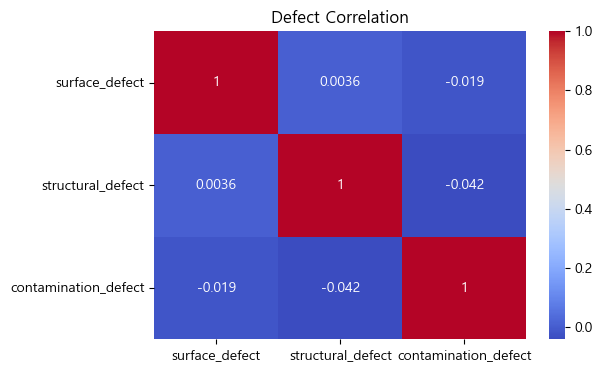

In [31]:
plt.figure(figsize=(6,4))
sns.heatmap(df_original_2[DEFECT_COLS].corr(), annot=True, cmap="coolwarm")
plt.title("Defect Correlation")
plt.show()

#### Process 변수 간 상관관계
- cycle_time <-> spray_time (0.92)
  - cycle_time이 길어지면 spray_time도 같이 길어짐
- high_velocity <-> spray_2_time (0.75)
  - high_velocity 높으면 spray_2_time이 길어지는 경향
- spray_time <-> spray_2_time (-0.83)
  - spray_time이 길면 spray_2_time은 짧아짐
- cycle_time <-> spray_2_time (-0.73)
  - cycle_time이 길어질수록 spray_2_time은 줄어듦
- high_velocity <-> clamping_force (-0.58)
  - high_velocity 빠르면 clamping_force는 낮아지는 경향

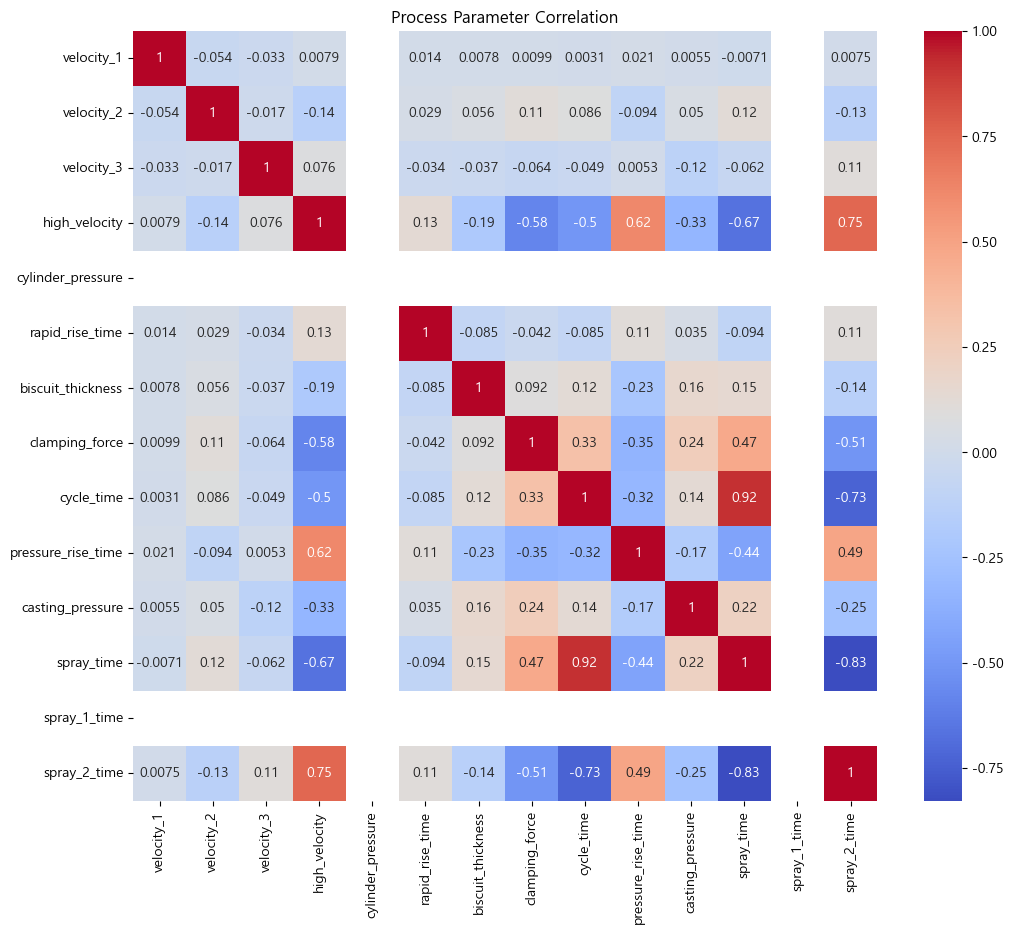

In [32]:
plt.figure(figsize=(12,10))
sns.heatmap(df_original_2[PROCESS_COLS].corr(), annot=True, cmap="coolwarm")
plt.title("Process Parameter Correlation")
plt.show()

### 불량 산점도 확인하기
#### 불량이 어디 구간에 몰리는지

- surface_defect

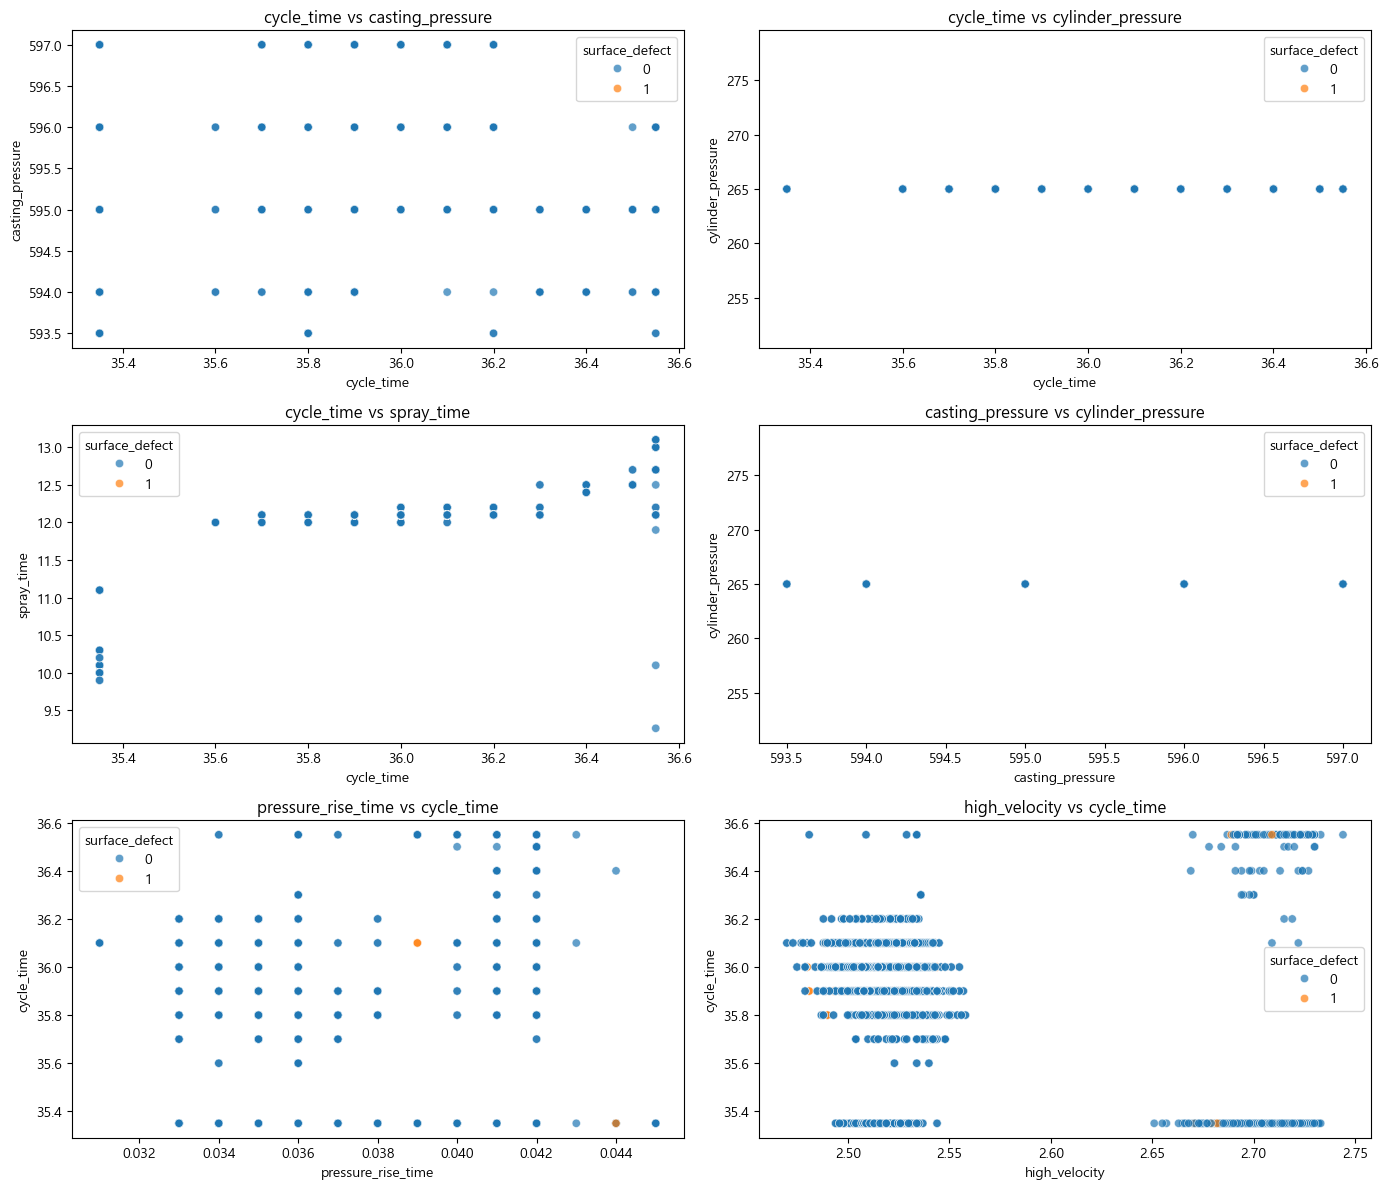

In [ ]:
scatter_pairs = [
    ("cycle_time", "casting_pressure"),
    ("cycle_time", "cylinder_pressure"),
    ("cycle_time", "spray_time"),
    ("casting_pressure", "cylinder_pressure"),
    ("pressure_rise_time", "cycle_time"),
    ("high_velocity", "cycle_time"),
]

plt.figure(figsize=(14, 12))

for i, (x, y) in enumerate(scatter_pairs):

    plt.subplot(3, 2, i+1)

    sns.scatterplot(
        x=x,
        y=y,
        hue="surface_defect",
        data=df_original_2,
        alpha=0.7
    )

    plt.title(f"{x} vs {y}")

plt.tight_layout()
plt.show()

- structural_defect

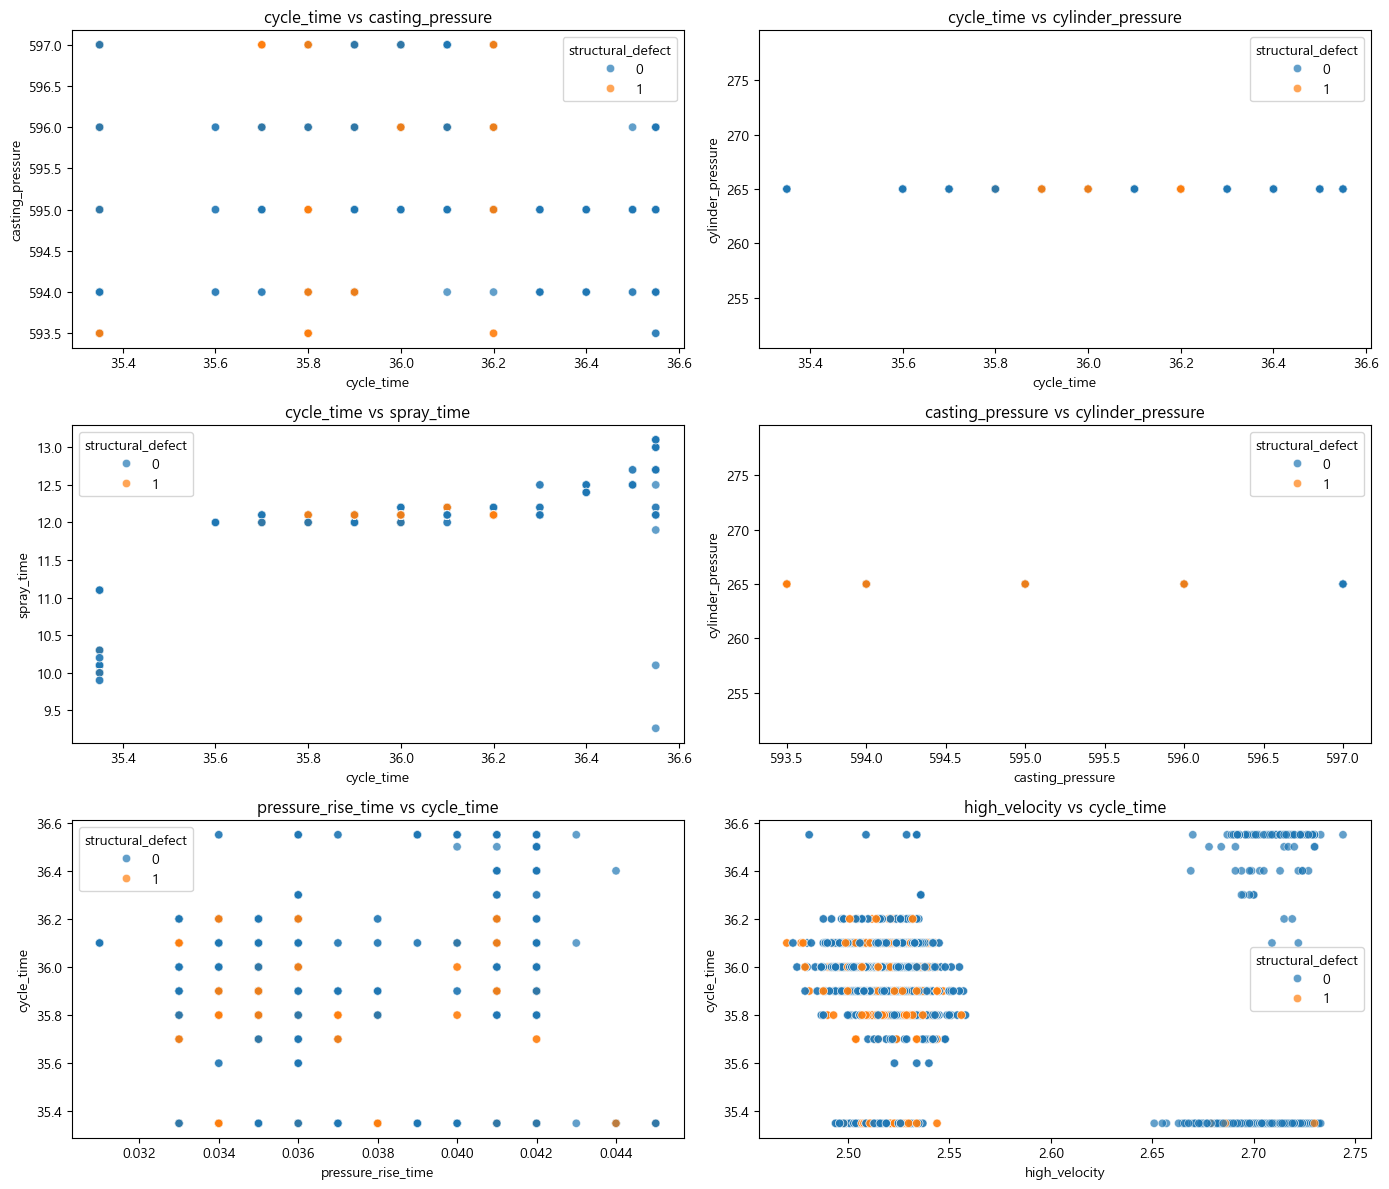

In [36]:
plt.figure(figsize=(14, 12))

for i, (x, y) in enumerate(scatter_pairs):

    plt.subplot(3, 2, i+1)

    sns.scatterplot(
        x=x,
        y=y,
        hue="structural_defect",
        data=df_original_2,
        alpha=0.7
    )

    plt.title(f"{x} vs {y}")

plt.tight_layout()
plt.show()

- contamination_defect

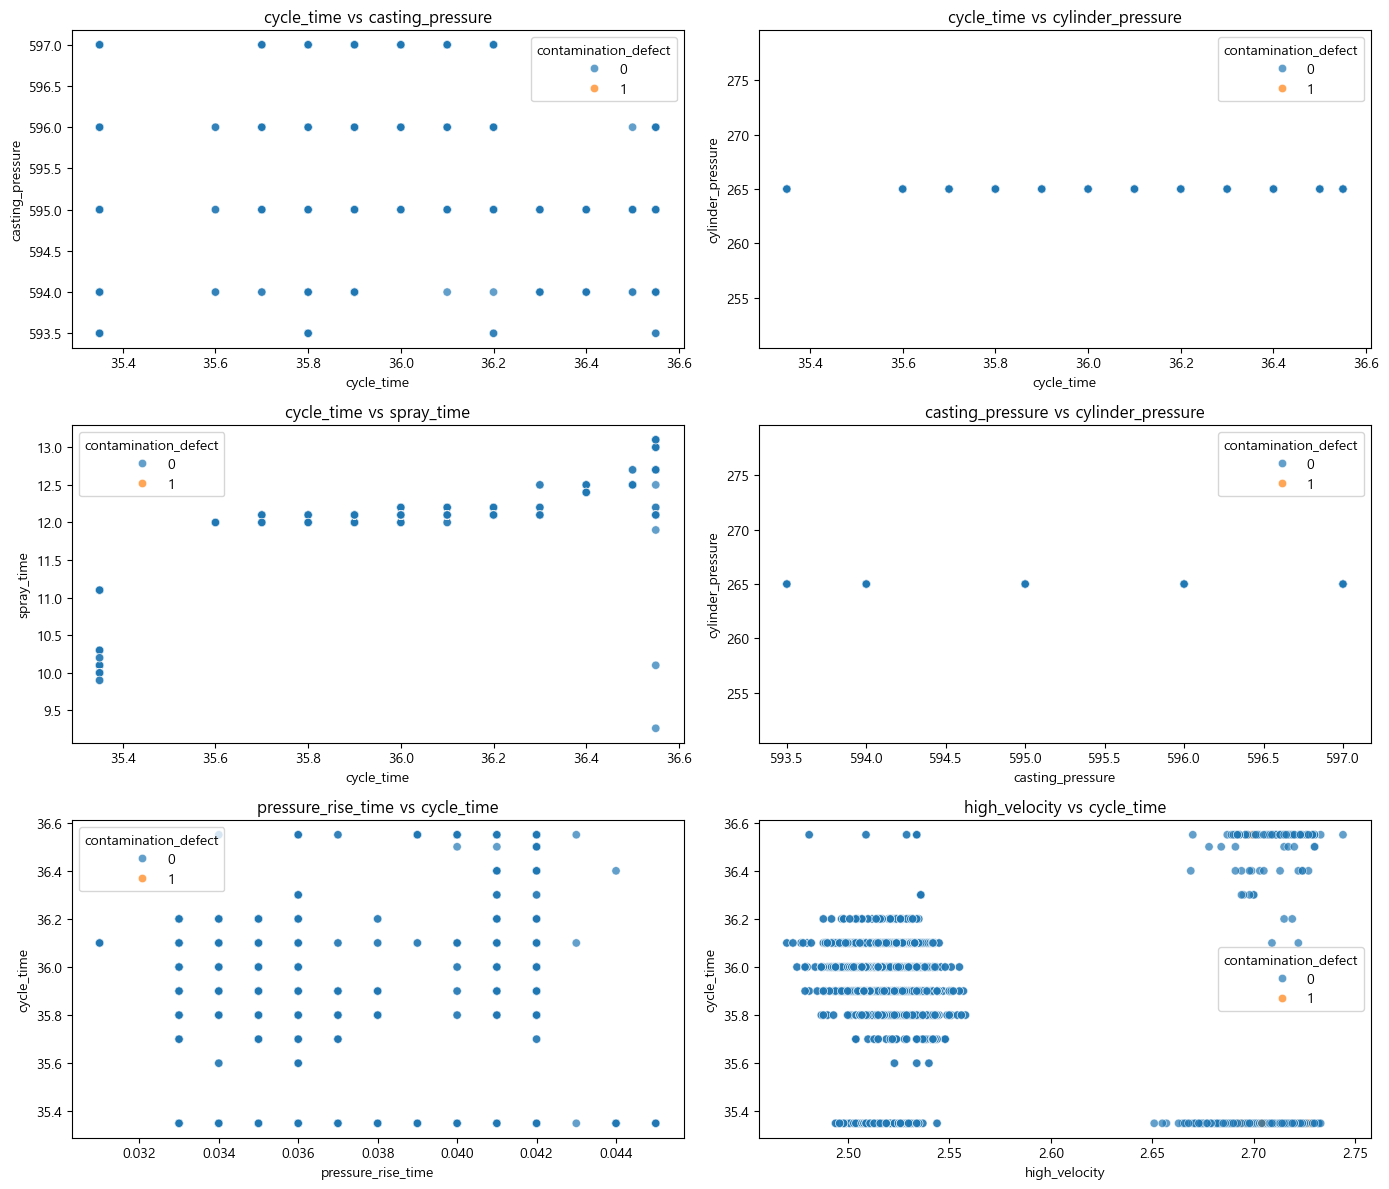

In [38]:
plt.figure(figsize=(14, 12))

for i, (x, y) in enumerate(scatter_pairs):

    plt.subplot(3, 2, i+1)

    sns.scatterplot(
        x=x,
        y=y,
        hue="contamination_defect",
        data=df_original_2,
        alpha=0.7
    )

    plt.title(f"{x} vs {y}")

plt.tight_layout()
plt.show()

### BOXPLOT (아직 못했음)

In [39]:
DEFECT_COLS = [
    'surface_defect',
    'structural_defect',
    'contamination_defect'
]

PROCESS_COLS = [
    'velocity_1', 'velocity_2', 'velocity_3', 'high_velocity',
    'cylinder_pressure', 'rapid_rise_time', 'biscuit_thickness',
    'clamping_force', 'cycle_time', 'pressure_rise_time',
    'casting_pressure', 'spray_time', 'spray_1_time', 'spray_2_time'
]


### B. 타깃이 3개 이상 다중 범주

In [35]:
df_defects_2["defect_type"] = np.select(
    [
        (df_defects_2["surface_defect"] == 0) & (df_defects_2["structural_defect"] == 0) & (df_defects_2["contamination_defect"] == 0),
        (df_defects_2["surface_defect"] == 1) & (df_defects_2["structural_defect"] == 0) & (df_defects_2["contamination_defect"] == 0),
        (df_defects_2["surface_defect"] == 0) & (df_defects_2["structural_defect"] == 1) & (df_defects_2["contamination_defect"] == 0),
        (df_defects_2["surface_defect"] == 0) & (df_defects_2["structural_defect"] == 0) & (df_defects_2["contamination_defect"] == 1),
        (df_defects_2[["surface_defect", "structural_defect", "contamination_defect"]].sum(axis=1) >= 2)
    ],
    [0, 1, 2, 3, 4],
    default=np.nan
)

display(df_defects_2["defect_type"].value_counts().sort_index())

defect_type
0.0    2382
1.0     149
2.0     731
3.0      19
4.0      47
Name: count, dtype: int64

0 = 정상\
1 = surface만\
2 = structural만\
3 = contamination만\
4 = 복합불량 (포함? 아마 해야하지 않을까 싶은데)


η² ≈ 0.01 → 작은 효과

η² ≈ 0.06 → 중간 효과

η² ≈ 0.14 이상 → 큰 효과

### One-way ANOVA (할필요는 없는것 같다.)